<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_7_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Practice Notebook

**You do not need to submit this Notebook.** It is for practice only.

## Introduction to the Dataset

The Titanic dataset contains information about passengers aboard the Titanic, including age, sex, ticket fare, and cabin class, and whether they survived the tragic sinking.

### Goal
We will use ensemble methods - specifically **VotingClassifier**, **RandomForestClassifier**, and **AdaBoostClassifier** - to predict which passengers survived the Titanic disaster. Ensemble methods combine multiple models to improve prediction accuracy.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import ensemble
from sklearn import linear_model
from sklearn import pipeline
from sklearn import svm
from sklearn import tree
from sklearn import metrics
from sklearn import model_selection
from sklearn import compose
from sklearn import preprocessing

In [2]:
seed = 42

## Load and Explore the Data

We'll load the Titanic dataset directly from a URL. This dataset contains both training data (with survival labels) and features about each passenger.

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.shape

(891, 12)

Let's check the shape and structure of our dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


There are some columns that may not be helpful, so for this exercise we will drop them.

Note: Aside from the ID, these columns may indeed be helpful with additional preprocessing, such as isolating surname or title from Name.

In [6]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

We can see that some columns have missing values, particularly Age and Cabin.

In [7]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


The number of null values for the Cabin column is quite high relative to the size of the dataset; in this case, we can remove it.

In [8]:
df = df.drop(columns="Cabin")

Conversely, Embarked has very few null values, so we can just remove those rows.

In [9]:
df = df.dropna(subset="Embarked")

How do we handle Age? Dropping the column seems too aggressive, yet removing that number of rows would have a big impact on such a small dataset. We will look at another strategy after splitting the data.

## Data Preprocessing

We start by creating a feature matrix and target vector.

In [10]:
X = df.drop(columns="Survived")
y = df["Survived"]
X.shape, y.shape

((889, 7), (889,))

Now we split our data into training and test sets. We'll use 80% for training and 20% for testing.

In [11]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=seed
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((711, 7), (711,), (178, 7), (178,))

With the data split, we can now deal with those null age values by taking the median of the training set for this column and filling in all null values with it.

In [12]:
median_age = X_train["Age"].median()
X_train["Age"] = X_train["Age"].fillna(median_age)
X_test["Age"] = X_test["Age"].fillna(median_age)

### Self-Check

Why do we use the median from the training set to fill in null values in the test set?

### Combining Columns

As seen previously, our preprocessing pipeline will use `make_column_transformer`. This will handle both categorical and numerical features appropriately.

In [13]:
transformer = compose.make_column_transformer(
    (
        # Standardize numerical features.
        preprocessing.StandardScaler(),
        compose.make_column_selector(dtype_include=np.number)
    ),
    (
        # Encode non-numerical features.
        preprocessing.OneHotEncoder(),
        compose.make_column_selector(dtype_include=object)
    ),
    verbose_feature_names_out=False
)

X_train_array = transformer.fit_transform(X_train)
X_test_array = transformer.transform(X_test)

Because the transformer returns NumPy arrays, we can pass them back into DataFrame constructors so we still can use Pandas methods.

In [14]:
tf_columns = transformer.get_feature_names_out()
X_train = pd.DataFrame(X_train_array, columns=tf_columns)
X_test = pd.DataFrame(X_test_array, columns=tf_columns)
X_train.shape, X_test.shape

((711, 10), (178, 10))

### Self-Check
Why do we fit the preprocessor on the training data but only transform the test data?

## VotingClassifier

A VotingClassifier combines multiple different models and makes predictions based on the majority vote (hard voting) or average predicted probabilities (soft voting). We'll start with three simple models: Logistic Regression, a Support Vector Machine, and a Decision Tree.

Note that SVC does not provide probabilities - which are needed for soft voting - unless its `probability` argument is set to True.

In [15]:
estimators = [
    (
        "Logistic Regression",
        linear_model.LogisticRegression(max_iter=1000, random_state=seed)
    ),
    (
        "SVM",
        svm.SVC(probability=True, random_state=seed)
    ),
    (
        "Decision Tree",
        tree.DecisionTreeClassifier(random_state=seed)
    )
]

voting_clf = ensemble.VotingClassifier(
    estimators=estimators,
    voting="soft"
)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

Let's evaluate the performance of our VotingClassifier and compare it with individual models.

In [16]:
accuracies = {}
for name, clf in estimators:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracies[name] = metrics.accuracy_score(y_test, y_pred)
accuracies["Voting Classifier"] = metrics.accuracy_score(y_test, y_pred_voting)
pd.Series(accuracies).sort_values(ascending=False).rename("accuracy")

,accuracy
SVM,0.820225
Voting Classifier,0.803371
Logistic Regression,0.775281
Decision Tree,0.735955


### Self-Check

Does the VotingClassifier perform better than individual models? Why or why not might this be the case?

### Try It Yourself

Modify the models used in the VotingClassifier. You could try changing hyperparameter values of the original models, or use different models, such as:

- `linear_model.SGDClassifier`
- `ensemble.GradientBoostingClassifier`
- `neighbors.KNeighborsClassifier`

Does changing the base models improve performance?

## RandomForestClassifier

Random Forest is an ensemble method that builds multiple decision trees and combines their predictions. Each tree is trained on a random subset of the data and features, which helps reduce overfitting and improve generalization.

In [17]:
rf_clf = ensemble.RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    max_depth=5,       # Maximum depth of each tree
    random_state=seed
)

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

rf_accuracy = metrics.accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

Random Forest Accuracy: 0.81


One advantage of Random Forest is that it can tell us which features are most important for making predictions.

In [18]:
pd.Series(
    rf_clf.feature_importances_, index=tf_columns
).sort_values(ascending=False).rename("importance")

,importance
Sex_male,0.296897
Sex_female,0.217971
Pclass,0.138813
Fare,0.132989
Age,0.084676
SibSp,0.055112
Parch,0.033339
Embarked_C,0.018067
Embarked_S,0.014644
Embarked_Q,0.007492


### Self-Check
Which features are most important for predicting survival? Does this make sense given what we know about the Titanic disaster?

### Tuning Random Forest Hyperparameters

A Random Forest has several hyperparameters we can tune:
- `n_estimators`: Number of trees in the forest (try values like 50, 100, 200)
- `max_depth`: Maximum depth of each tree (try values like 3, 5, 10, None)
- `min_samples_split`: Minimum samples required to split a node (try values like 2, 5, 10)
- `min_samples_leaf`: Minimum samples required at a leaf node (try values like 1, 2, 4)

n_estimators=10: Accuracy=0.8034
n_estimators=50: Accuracy=0.7640
n_estimators=100: Accuracy=0.7697
n_estimators=200: Accuracy=0.7753


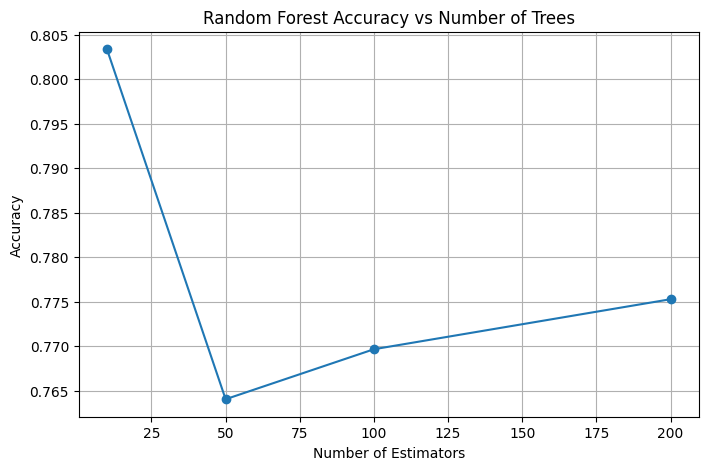

In [19]:
n_estimators_values = [10, 50, 100, 200]
accuracies = []

for n_est in n_estimators_values:
    rf = ensemble.RandomForestClassifier(n_estimators=n_est, random_state=seed)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"n_estimators={n_est}: Accuracy={acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_values, accuracies, marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()

### Try It Yourself

Experiment with different values of `max_depth`. Does increasing or decreasing the tree depth improve performance?

## AdaBoostClassifier

AdaBoost (Adaptive Boosting) is another ensemble method that builds models sequentially. Each new model focuses on the examples that previous models got wrong, gradually improving overall performance. Unlike Random Forest, AdaBoost typically uses very simple models called Decision Stumps (Decision Trees with only one split).

In [20]:
ada_clf = ensemble.AdaBoostClassifier(
    n_estimators=50,      # Number of weak learners
    learning_rate=1.0,    # Weight applied to each classifier
    random_state=seed
)

ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

ada_accuracy = metrics.accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")

AdaBoost Accuracy: 0.7978


### Tuning AdaBoost Hyperparameters

AdaBoost has two main hyperparameters:
- `n_estimators`: Number of weak learners to train (try values like 25, 50, 100)
- `learning_rate`: Controls how much each weak learner contributes (try values like 0.5, 1.0, 2.0)

learning_rate=0.1: Accuracy=0.7978
learning_rate=0.5: Accuracy=0.8090
learning_rate=1.0: Accuracy=0.7978
learning_rate=1.5: Accuracy=0.8034
learning_rate=2.0: Accuracy=0.2022


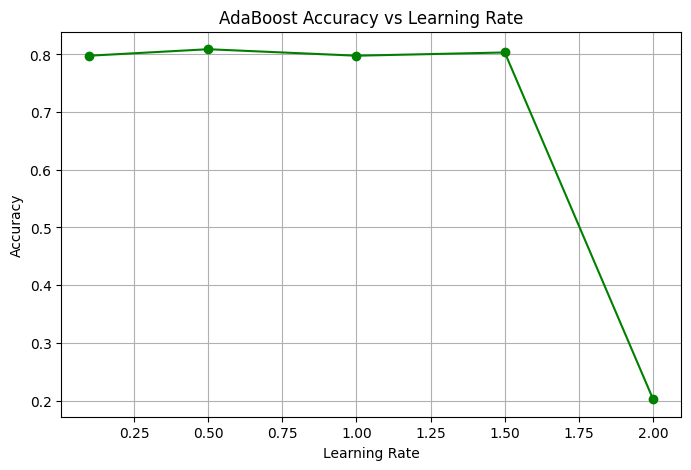

In [21]:
learning_rates = [0.1, 0.5, 1.0, 1.5, 2.0]
ada_accuracies = []

for lr in learning_rates:
    ada = ensemble.AdaBoostClassifier(
        n_estimators=50,
        learning_rate=lr,
        random_state=seed
    )
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    ada_accuracies.append(acc)
    print(f"learning_rate={lr}: Accuracy={acc:.4f}")

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, ada_accuracies, marker="o", color="green")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("AdaBoost Accuracy vs Learning Rate")
plt.grid(True)
plt.show()

### Self-Check
What happens to AdaBoost's performance as we increase the learning rate? Is there an optimal value?

### Try It Yourself

Experiment with the `n_estimators` parameter. How does the number of weak learners affect performance?

## Comparing All Models

Let's compare the performance of all our ensemble methods side by side.

In [22]:
models = {
    "Voting Classifier": voting_clf,
    "Random Forest": rf_clf,
    "AdaBoost": ada_clf
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1-Score
Voting Classifier,0.803371,0.750000,0.739130,0.744526
Random Forest,0.814607,0.772727,0.739130,0.755556
AdaBoost,0.797753,0.720000,0.782609,0.750000


## What's Next?

You are encouraged to experiment further with these ensemble methods:

**For VotingClassifier:**
- Experiment with "hard" vs "soft" voting
- Add more diverse models to the ensemble

**For RandomForestClassifier:**
- Tune `max_features` to control how many features each tree considers
- Adjust `min_samples_split` and `min_samples_leaf` to control tree complexity

**For AdaBoostClassifier:**
- Experiment with different base estimators using the `estimator` parameter
- Combine different learning rates with different numbers of estimators

See this week's Canvas module for more information about ensemble learning and when to use each method.